In [1]:
# Set up the file path
import os
os.chdir('..')

In [2]:
# Import packages
from RL4CRN.iocrns.reactions import ActiveDegradation
from RL4CRN.iocrns.reactions import HillProduction
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC
import numpy as np

In [3]:
# Construct library from a list of reactions
rxn_0 = MassAction(reactant_labels=['Z'], product_labels=[], input_channels=['u_1'], params=[1], params_controllability=[True])
rxn_1 = MassAction(reactant_labels=['X_2', 'Z'], product_labels=['X_2', 'Z', 'Z'], input_channels=[None], params=[1], params_controllability=[True])
rxn_2 = MassAction(reactant_labels=[], product_labels=['X_1'], input_channels=['u_2'], params=[1], params_controllability=[True])
rxn_3 = HillProduction(product_labels=['X_2'], activator_labels=['X_1'], repressor_labels=[], input_channels=['u_3', 'u_4', 'u_5'], params=[1., 1., 1.], params_controllability=[True, True, True])
rxn_4 = MassAction(reactant_labels=['X_1'], product_labels=[], input_channels=['u_6'], params=[0.1], params_controllability=[True])
rxn_5 = MassAction(reactant_labels=['X_2'], product_labels=[], input_channels=['u_7'], params=[0.1], params_controllability=[True])
rxn_6 = ActiveDegradation(substrate_label=['X_1'], enzyme_label=['Z'], input_channels=['u_8', 'u_9'], params=[1.0, 1.0], params_controllability=[True, True])

In [4]:
# Print details
print('Reaction 0:')
print(rxn_0)
print('Signature:', rxn_0.signature)
print('Parameters:', rxn_0.params)
print('Inputs:', rxn_0.input_channels)
print('Rate constant:', rxn_0.rate_constant)
print('----------------------------------')

print('Reaction 1:')
print(rxn_1)
print('Signature:', rxn_1.signature)
print('Parameters:', rxn_1.params)
print('Inputs:', rxn_1.input_channels)
print('Rate constant:', rxn_1.rate_constant)
print('----------------------------------')

print('Reaction 2:')
print(rxn_2)
print('Signature:', rxn_2.signature)
print('Parameters:', rxn_2.params)
print('Inputs:', rxn_2.input_channels)
print('Rate constant:', rxn_2.rate_constant)
print('----------------------------------')

print('Reaction 3:')
print(rxn_3)
print('Signature:', rxn_3.signature)
print('Parameters:', rxn_3.params)
print('Inputs:', rxn_3.input_channels)
print('Basal rate:', rxn_3.basal_rate)
print('Maximal rate:', rxn_3.maximal_rate)
print('Activator dissociation constants:', rxn_3.activator_dissociation_constants)
print('Repressor dissociation constants:', rxn_3.repressor_dissociation_constants)
print('----------------------------------')

print('Reaction 4:')
print(rxn_4)
print('Signature:', rxn_4.signature)
print('Parameters:', rxn_4.params)
print('Inputs:', rxn_4.input_channels)
print('Rate constant:', rxn_4.rate_constant)
print('----------------------------------')

print('Reaction 5:')
print(rxn_5)
print('Signature:', rxn_5.signature)
print('Parameters:', rxn_5.params)
print('Inputs:', rxn_5.input_channels)
print('Rate constant:', rxn_5.rate_constant)
print('----------------------------------')

print('Reaction 6:')
print(rxn_6)
print('Signature:', rxn_6.signature)
print('Parameters:', rxn_6.params)
print('Inputs:', rxn_6.input_channels)
print('Maximal rate:', rxn_6.maximal_rate)
print('Michaelis constant:', rxn_6.michaelis_constant)
print('----------------------------------')


Reaction 0:
Z ----> ∅;  [MAK(1, u_1)]
Signature: ('MAK', ['Z'], [])
Parameters: [1]
Inputs: ['u_1']
Rate constant: 1
----------------------------------
Reaction 1:
X_2 + Z ----> X_2 + Z + Z;  [MAK(1)]
Signature: ('MAK', ['X_2', 'Z'], ['X_2', 'Z', 'Z'])
Parameters: [1]
Inputs: [None]
Rate constant: 1
----------------------------------
Reaction 2:
∅ ----> X_1;  [MAK(1, u_2)]
Signature: ('MAK', [], ['X_1'])
Parameters: [1]
Inputs: ['u_2']
Rate constant: 1
----------------------------------
Reaction 3:
∅ ----> X_2;  [HILLProd(b = 1.0u_3, Vm = 1.0u_4,    (Ka, na) = X_1(1.0u_5, 1);    (Kr, nr) = )]
Signature: ('HILLProd', ['X_2'], ['X_1'], [])
Parameters: [1.0, 1.0, 1.0]
Inputs: ['u_3', 'u_4', 'u_5']
Basal rate: 1.0
Maximal rate: 1.0
Activator dissociation constants: [1.0]
Repressor dissociation constants: []
----------------------------------
Reaction 4:
X_1 ----> ∅;  [MAK(0.1, u_6)]
Signature: ('MAK', ['X_1'], [])
Parameters: [0.1]
Inputs: ['u_6']
Rate constant: 0.1
-----------------------

In [5]:
# Construct CRN
crn = IOCRN(reactions=[rxn_0, rxn_1, rxn_2, rxn_3, rxn_4, rxn_5, rxn_6], output_labels=['X_1', 'X_2', 'Z'])
crn.compile()
print(crn)

Inputs: ['u_1', 'u_2', 'u_3', 'u_4', 'u_5', 'u_6', 'u_7', 'u_8', 'u_9'] 
Species: ['X_1', 'X_2', 'Z'] 
Output Species: ['X_1', 'X_2', 'Z'] 
Z ----> ∅;  [MAK(1, u_1)]
X_2 + Z ----> X_2 + Z + Z;  [MAK(1)]
∅ ----> X_1;  [MAK(1, u_2)]
∅ ----> X_2;  [HILLProd(b = 1.0u_3, Vm = 1.0u_4,    (Ka, na) = X_1(1.0u_5, 1);    (Kr, nr) = )]
X_1 ----> ∅;  [MAK(0.1, u_6)]
X_2 ----> ∅;  [MAK(0.1, u_7)]
X_1 ----> ∅;  [ActiveDeg(E = ['Z'],    a = 1.0u_8,    K = 1.0u_9)]


In [6]:
# Stoichiometry matrix
print('Stoichiometry matrix:')
print(crn.get_stoichiometry_matrix())
print('----------------------------------')

# Propensity evaluation
x = np.array([1., 2., 3.])
u = np.array([1., 2., 3., 4., 5., 6., 7., 8., 9.])
for i, rxn in enumerate(crn.reactions):
    a = rxn.propensity(x, u)
    print(f'Propensity of reaction {i}: {a}')

Stoichiometry matrix:
[[ 0.  0.  1.  0. -1.  0. -1.]
 [ 0.  0.  0.  1.  0. -1.  0.]
 [-1.  1.  0.  0.  0.  0.  0.]]
----------------------------------
Propensity of reaction 0: 3.0
Propensity of reaction 1: 6.0
Propensity of reaction 2: 2.0
Propensity of reaction 3: 3.6666666666666665
Propensity of reaction 4: 0.6000000000000001
Propensity of reaction 5: 1.4000000000000001
Propensity of reaction 6: 2.4


In [7]:
prop_test = np.array([3*1, 2*3*1, 2*1, 3 + 4*1/(1+5), 6*0.1*1, 7*0.1*2, 8*3*1/(9+1)])
print("Propensity test:", prop_test)

Propensity test: [3.         6.         2.         3.66666667 0.6        1.4
 2.4       ]


In [8]:
# List of initial conditions for IOCRN
ic = IC(names=['X_1', 'X_2', 'Z'], values=[[1., 1., 1.]])
x0_list = ic.get_ic(crn)
print("Initial Conditions:", x0_list)

# Inputs for IOCRN
u_list = [[1., 1.0, 0, 1., 1., 1., 1., 1., 1.]]

Initial Conditions: [array([1., 1., 1.])]


(<Figure size 1000x1500 with 3 Axes>,
 array([<Axes: title={'center': 'Transient Response of Output Species X_1'}, xlabel='Time', ylabel='Concentration'>,
        <Axes: title={'center': 'Transient Response of Output Species X_2'}, xlabel='Time', ylabel='Concentration'>,
        <Axes: title={'center': 'Transient Response of Output Species Z'}, xlabel='Time', ylabel='Concentration'>],
       dtype=object))

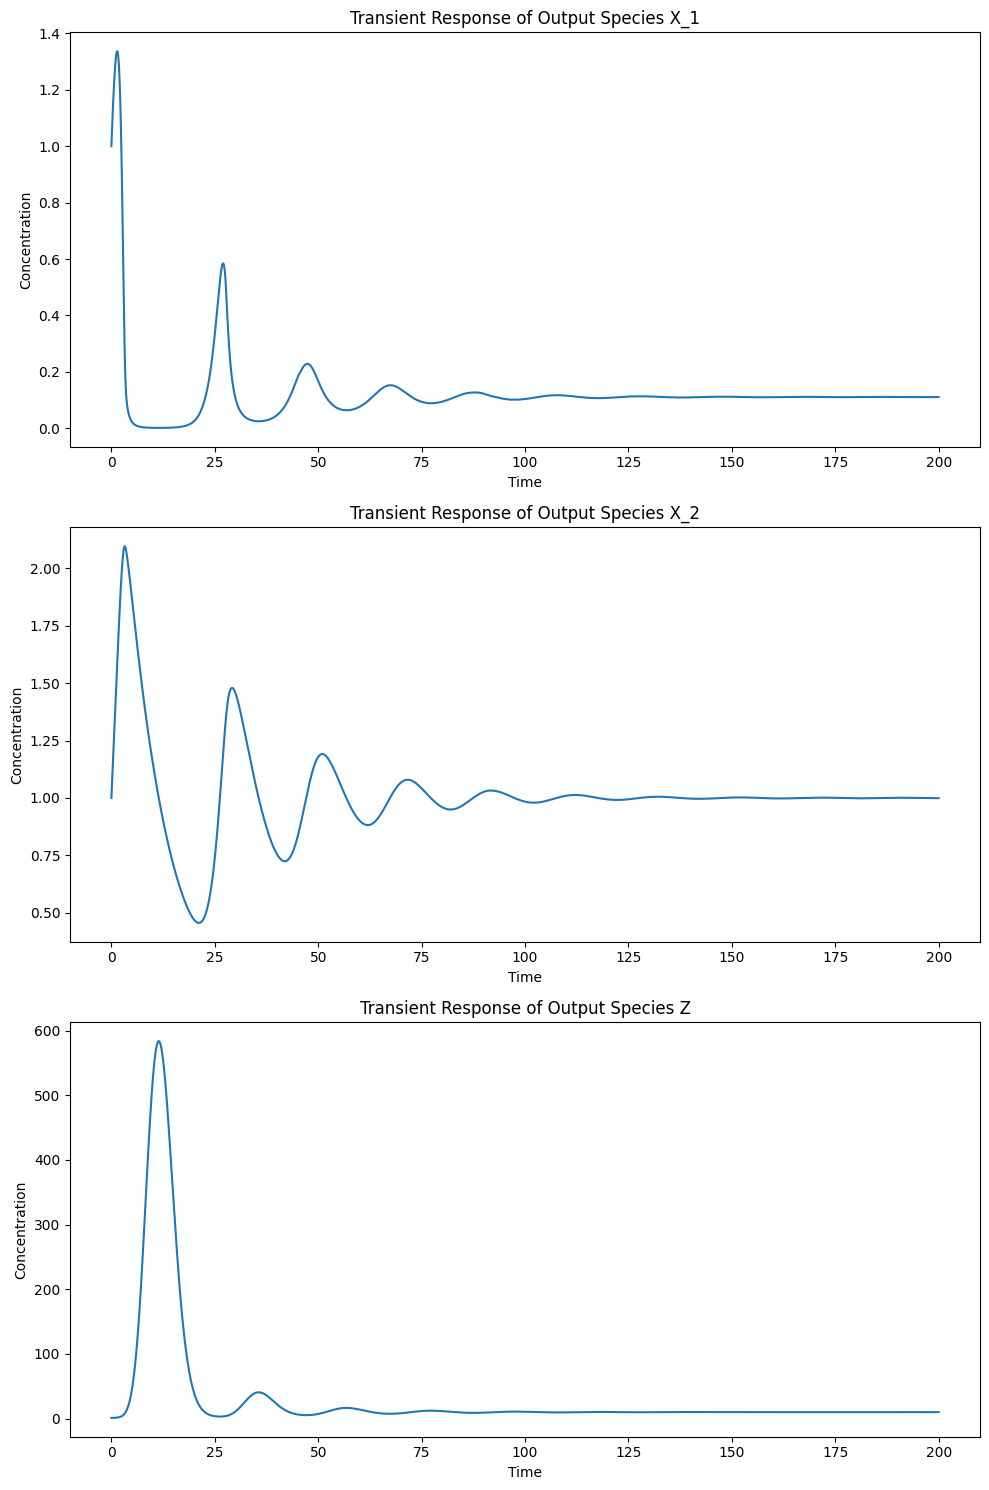

In [9]:
# Simulate dynamics
time_horizon = np.linspace(0, 200, 10000)
crn.reset()
crn.transient_response(u_list, x0_list, time_horizon)
crn.plot_transient_response(alpha=1)